<a href="https://colab.research.google.com/github/karthick-1977/HR-Employee-Attrition-Analysis/blob/main/HR_Employee_Attrition_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from IPython.display import display

data = {
    "EmployeeID": [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30],
    "EmployeeName": [
        "Kabil","Arun","Divya","Vijay","Meena","Raja","Priya","Suresh","Kavya","Mohan",
        "Anitha","Karthik","Sneha","Prakash","Keerthi","Manoj","Nivetha","Bala","Ramya","Santhosh",
        "Asha","Dinesh","Janani","Gokul","Swetha","Harish","Monisha","Naveen","Lakshmi","Surya"
    ],
    "Gender": [
        "Male","Male","Female","Male","Female","Male","Female","Male","Female","Male",
        "Female","Male","Female","Male","Female","Male","Female","Male","Female","Male",
        "Female","Male","Female","Male","Female","Male","Female","Male","Female","Male"
    ],
    "Age": [
        25,30,28,35,22,40,27,32,29,45,
        26,34,31,24,36,39,23,33,41,28,
        37,26,30,42,25,38,27,44,29,35
    ],
    "Department": [
        "IT","HR","IT","IT","Sales","HR","IT","Sales","HR","IT",
        "Sales","IT","HR","Sales","Finance","Finance","IT","Sales","HR","Finance",
        "IT","Sales","Finance","IT","HR","Sales","Finance","IT","Sales","HR"
    ],
    "MonthlyIncome": [
        30000,40000,35000,50000,25000,60000,32000,45000,38000,70000,
        28000,52000,42000,27000,55000,62000,29000,47000,65000,36000,
        58000,31000,44000,72000,33000,56000,37000,75000,39000,51000
    ],
    "YearsAtCompany": [
        2,5,3,7,1,10,2,6,4,12,
        2,8,5,1,9,11,1,6,13,3,
        9,2,5,14,2,10,3,15,4,7
    ],
    "OverTime": [
        "Yes","No","Yes","No","Yes","No","Yes","No","Yes","No",
        "Yes","No","No","Yes","No","No","Yes","No","No","Yes",
        "No","Yes","No","No","Yes","No","Yes","No","Yes","No"
    ],
    "JobSatisfaction": [
        3,4,2,4,2,5,3,4,2,5,
        2,4,4,2,5,4,2,3,5,3,
        4,2,4,5,3,4,3,5,2,4
    ],
    "WorkLifeBalance": [
        3,4,2,4,2,4,2,3,2,5,
        2,4,3,2,4,4,2,3,5,2,
        4,2,3,5,2,4,3,5,2,4
    ],
    "DistanceFromHome": [
        8,5,12,6,15,4,10,7,13,3,
        14,6,8,16,5,7,18,9,4,11,
        6,17,8,3,12,5,10,2,14,6
    ],
    "Attrition": [
        "No","No","Yes","No","Yes","No","Yes","No","Yes","No",
        "Yes","No","No","Yes","No","No","Yes","No","No","Yes",
        "No","Yes","No","No","Yes","No","Yes","No","Yes","No"
    ]
}

df = pd.DataFrame(data)

output_folder = "HR_Employee_Attrition_Project"
os.makedirs(output_folder, exist_ok=True)
df.to_csv(os.path.join(output_folder, "hr_attrition.csv"), index=False)

print("HR EMPLOYEE ATTRITION ANALYSIS")
print("=" * 40)

print("\nFirst 5 Employee Records")
display(df.head())

print("\nTotal Employees:", len(df))

print("\nSalary Analysis")
print("Average Monthly Income:", round(df["MonthlyIncome"].mean(), 2))
print("Highest Monthly Income:", df["MonthlyIncome"].max())
print("Lowest Monthly Income:", df["MonthlyIncome"].min())

attrition_count = df["Attrition"].value_counts().reindex(["No", "Yes"]).fillna(0).astype(int)
attrition_rate = (attrition_count["Yes"] / len(df)) * 100

print("\nAttrition Count")
print(attrition_count)

print("\nAttrition Rate:", round(attrition_rate, 2), "%")

department_attrition = pd.crosstab(df["Department"], df["Attrition"]).reindex(columns=["No", "Yes"], fill_value=0)
gender_attrition = pd.crosstab(df["Gender"], df["Attrition"]).reindex(columns=["No", "Yes"], fill_value=0)
overtime_attrition = pd.crosstab(df["OverTime"], df["Attrition"]).reindex(columns=["No", "Yes"], fill_value=0)
job_satisfaction_attrition = pd.crosstab(df["JobSatisfaction"], df["Attrition"]).reindex(columns=["No", "Yes"], fill_value=0)
work_life_attrition = pd.crosstab(df["WorkLifeBalance"], df["Attrition"]).reindex(columns=["No", "Yes"], fill_value=0)
income_analysis = df.groupby("Attrition")["MonthlyIncome"].mean().reindex(["No", "Yes"])

print("\nDepartment-wise Attrition")
display(department_attrition)

print("\nGender-wise Attrition")
display(gender_attrition)

print("\nOverTime-wise Attrition")
display(overtime_attrition)

print("\nJob Satisfaction-wise Attrition")
display(job_satisfaction_attrition)

print("\nWork-Life Balance-wise Attrition")
display(work_life_attrition)

PRIMARY_BLUE = "#0B3D91"
GREY = "#9AA4B2"
LIGHT_GREY = "#E6EEF7"
DARK_TEXT = "#202124"
WHITE = "#FFFFFF"

plt.rcParams.update({
    "figure.facecolor": WHITE,
    "axes.facecolor": WHITE,
    "axes.edgecolor": LIGHT_GREY,
    "axes.labelcolor": DARK_TEXT,
    "xtick.color": DARK_TEXT,
    "ytick.color": DARK_TEXT,
    "text.color": DARK_TEXT,
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "legend.frameon": True,
    "legend.facecolor": WHITE,
    "legend.edgecolor": LIGHT_GREY
})

def save_chart(filename):
    path = os.path.join(output_folder, filename)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight", facecolor=WHITE)
    plt.show()
    plt.close()

def style_chart(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=17, fontweight="bold", color=PRIMARY_BLUE, pad=15)
    ax.set_xlabel(xlabel, fontsize=12, fontweight="bold", color=DARK_TEXT)
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold", color=DARK_TEXT)
    ax.grid(axis="y", linestyle="--", alpha=0.25, color=LIGHT_GREY)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(LIGHT_GREY)
    ax.spines["bottom"].set_color(LIGHT_GREY)

def add_labels(ax):
    for container in ax.containers:
        try:
            ax.bar_label(container, fontsize=10, padding=3, color=PRIMARY_BLUE, fontweight="bold")
        except:
            pass

def grouped_bar_chart(table, title, xlabel, filename):
    fig, ax = plt.subplots(figsize=(8, 5.2), dpi=120)
    table.plot(kind="bar", ax=ax, color=[PRIMARY_BLUE, GREY], edgecolor=WHITE, linewidth=1.5, width=0.72)
    style_chart(ax, title, xlabel, "Number of Employees")
    ax.legend(["Stayed", "Left"], title="Status")
    plt.xticks(rotation=0)
    add_labels(ax)
    save_chart(filename)

counts = attrition_count.reindex(["No", "Yes"])
labels = ["Stayed", "Left"]
values = [counts["No"], counts["Yes"]]

HR EMPLOYEE ATTRITION ANALYSIS

First 5 Employee Records


,EmployeeID,EmployeeName,Gender,Age,Department,MonthlyIncome,YearsAtCompany,OverTime,JobSatisfaction,WorkLifeBalance,DistanceFromHome,Attrition
0,1,Kabil,Male,25,IT,30000,2,Yes,3,3,8,No
1,2,Arun,Male,30,HR,40000,5,No,4,4,5,No
2,3,Divya,Female,28,IT,35000,3,Yes,2,2,12,Yes
3,4,Vijay,Male,35,IT,50000,7,No,4,4,6,No
4,5,Meena,Female,22,Sales,25000,1,Yes,2,2,15,Yes



Total Employees: 30

Salary Analysis
Average Monthly Income: 45466.67
Highest Monthly Income: 75000
Lowest Monthly Income: 25000

Attrition Count
Attrition
No     18
Yes    12
Name: count, dtype: int64

Attrition Rate: 40.0 %

Department-wise Attrition


Attrition,No,Yes
Department,,
Finance,3,2
HR,5,2
IT,7,3
Sales,3,5



Gender-wise Attrition


...

Attrition,No,Yes
OverTime,,
No,17,0
Yes,1,12



Job Satisfaction-wise Attrition


Attrition,No,Yes
JobSatisfaction,,
2,0,8
3,2,4
4,10,0
5,6,0



Work-Life Balance-wise Attrition


Attrition,No,Yes
WorkLifeBalance,,
2,0,11
3,5,1
4,9,0
5,4,0


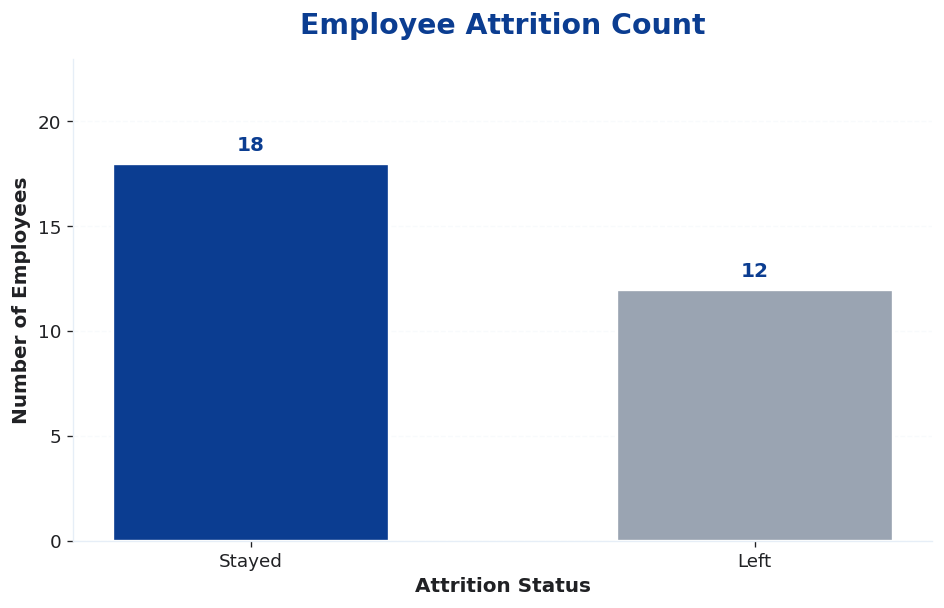

In [2]:
fig, ax = plt.subplots(figsize=(8, 5.2), dpi=120)

bars = ax.bar(
    labels,
    values,
    color=[PRIMARY_BLUE, GREY],
    width=0.55,
    edgecolor=WHITE,
    linewidth=2
)

style_chart(ax, "Employee Attrition Count", "Attrition Status", "Number of Employees")
ax.set_ylim(0, max(values) + 5)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.4,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color=PRIMARY_BLUE
    )

save_chart("01_attrition_count_chart.png")

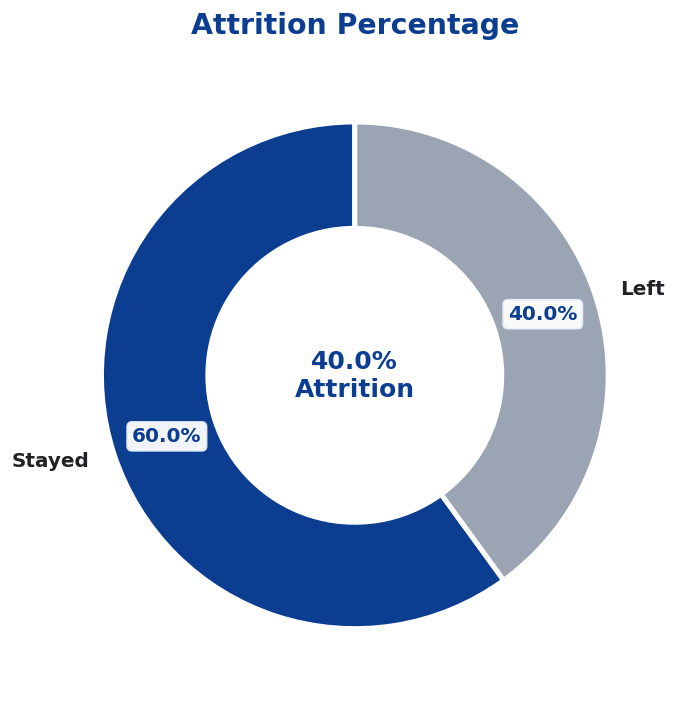

In [3]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=[PRIMARY_BLUE, GREY],
    pctdistance=0.78,
    wedgeprops={"width": 0.42, "edgecolor": WHITE, "linewidth": 3},
    textprops={"fontsize": 12, "fontweight": "bold", "color": DARK_TEXT}
)

for autotext in autotexts:
    autotext.set_color(PRIMARY_BLUE)
    autotext.set_fontweight("bold")
    autotext.set_fontsize(12)
    autotext.set_bbox({
        "facecolor": WHITE,
        "edgecolor": LIGHT_GREY,
        "boxstyle": "round,pad=0.25",
        "alpha": 0.95
    })

for text in texts:
    text.set_color(DARK_TEXT)
    text.set_fontweight("bold")

ax.text(
    0,
    0,
    f"{round(attrition_rate, 1)}%\nAttrition",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold",
    color=PRIMARY_BLUE
)

ax.set_title("Attrition Percentage", fontsize=17, fontweight="bold", color=PRIMARY_BLUE, pad=15)

save_chart("02_attrition_donut_chart.png")

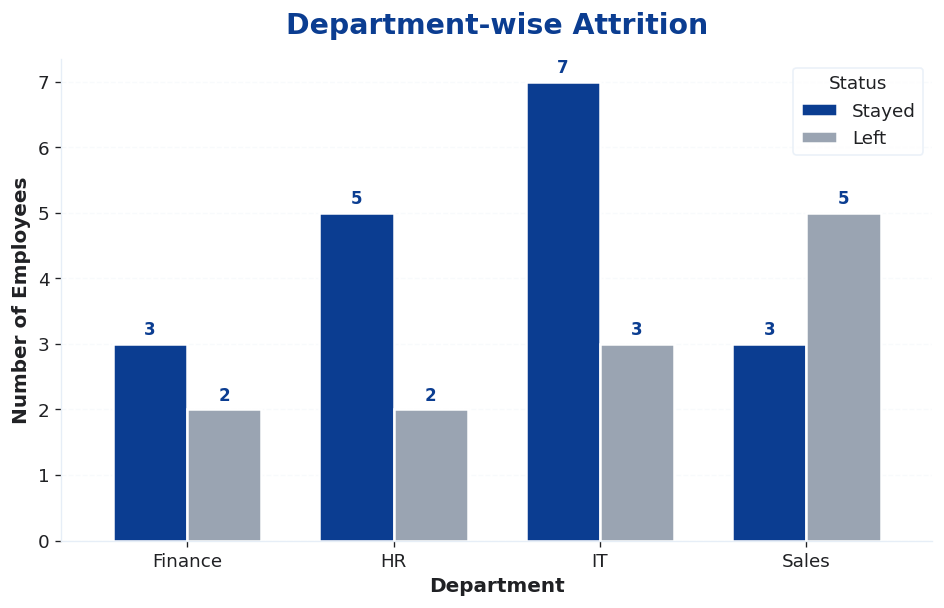

In [4]:
grouped_bar_chart(
    department_attrition,
    "Department-wise Attrition",
    "Department",
    "03_department_attrition_chart.png"
)

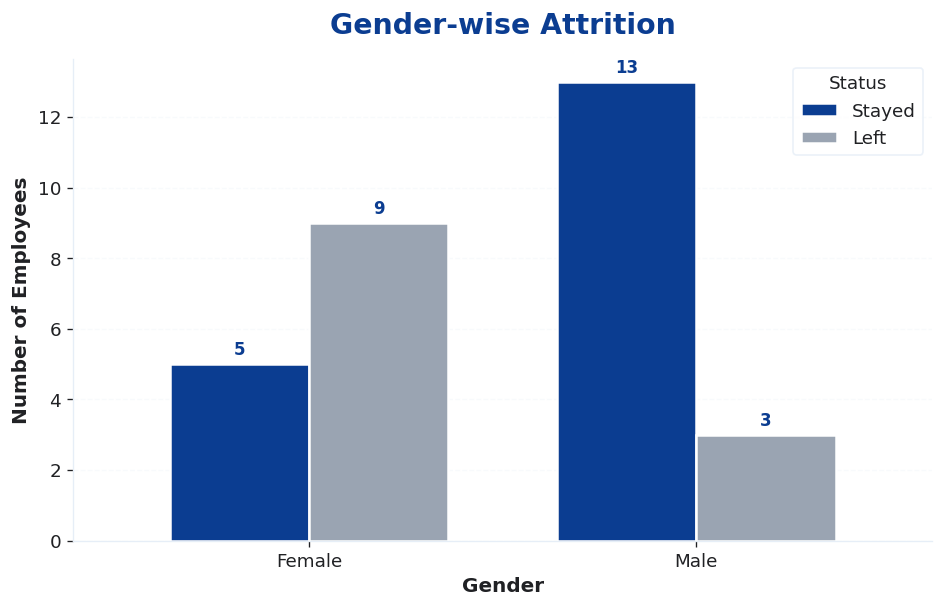

In [5]:
grouped_bar_chart(
    gender_attrition,
    "Gender-wise Attrition",
    "Gender",
    "04_gender_attrition_chart.png"
)

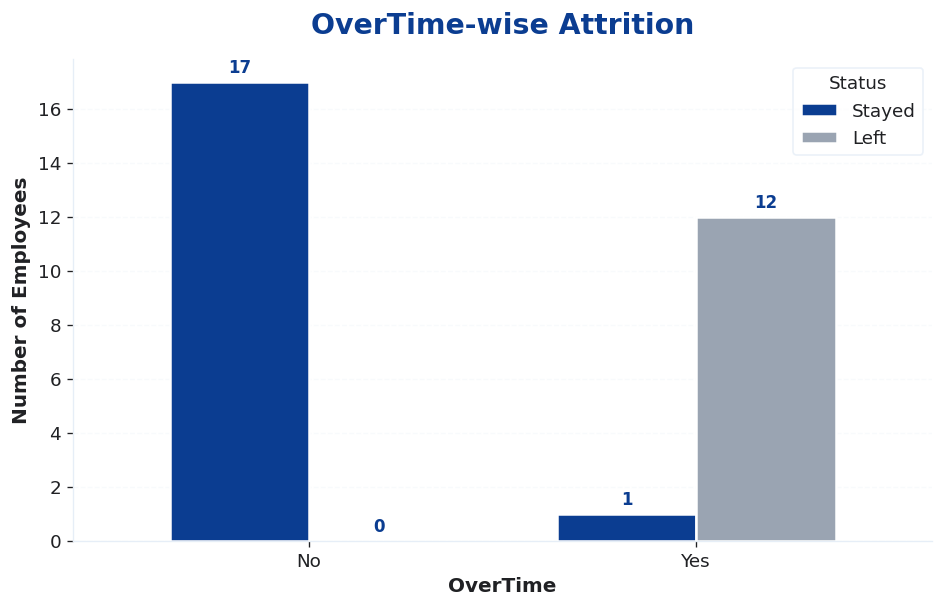

In [6]:
grouped_bar_chart(
    overtime_attrition,
    "OverTime-wise Attrition",
    "OverTime",
    "05_overtime_attrition_chart.png"
)

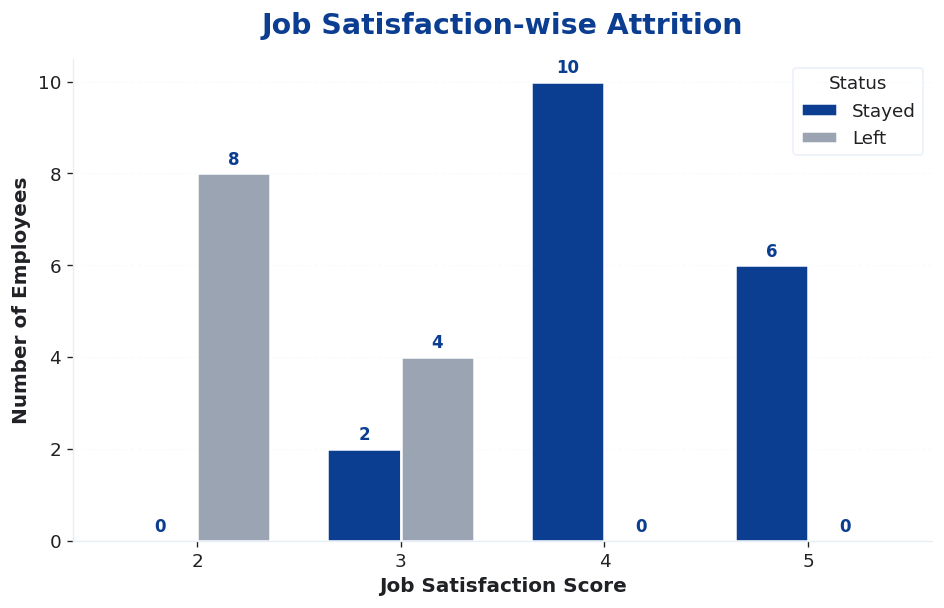

In [7]:
grouped_bar_chart(
    job_satisfaction_attrition,
    "Job Satisfaction-wise Attrition",
    "Job Satisfaction Score",
    "06_job_satisfaction_attrition_chart.png"
)

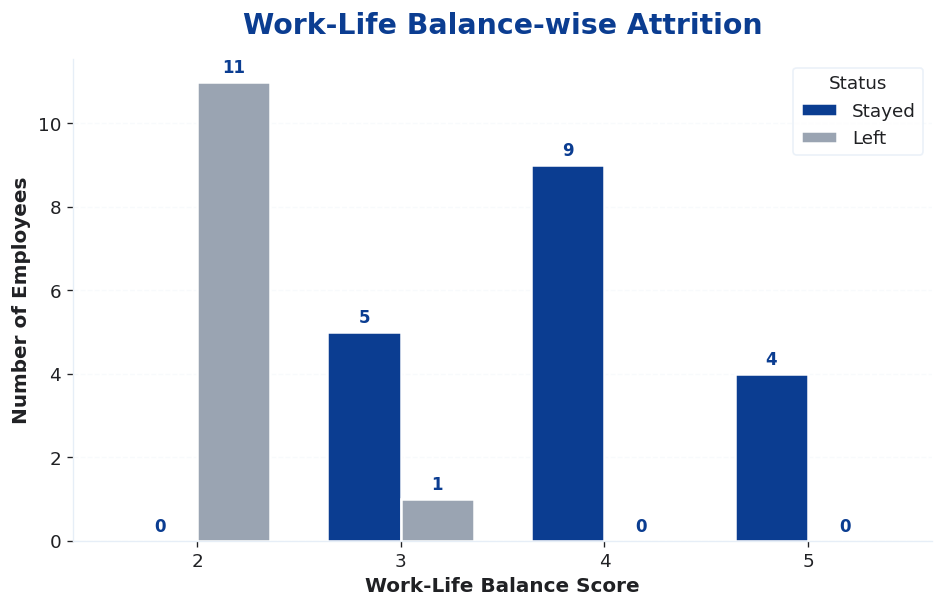

In [8]:
grouped_bar_chart(
    work_life_attrition,
    "Work-Life Balance-wise Attrition",
    "Work-Life Balance Score",
    "07_work_life_balance_chart.png"
)

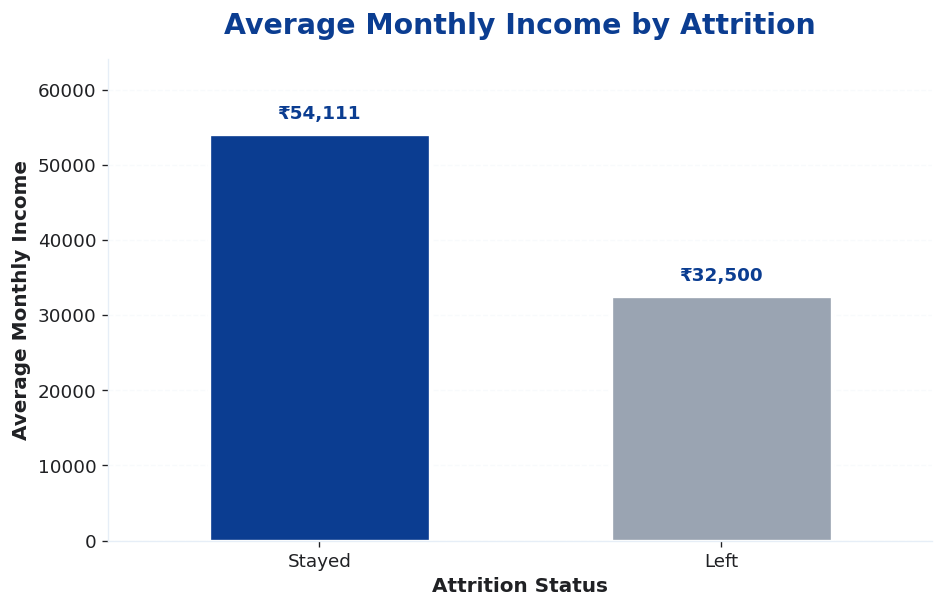

In [9]:
fig, ax = plt.subplots(figsize=(8, 5.2), dpi=120)

income_analysis.plot(
    kind="bar",
    ax=ax,
    color=[PRIMARY_BLUE, GREY],
    edgecolor=WHITE,
    linewidth=2,
    width=0.55
)

style_chart(ax, "Average Monthly Income by Attrition", "Attrition Status", "Average Monthly Income")
plt.xticks(ticks=[0, 1], labels=["Stayed", "Left"], rotation=0)
ax.set_ylim(0, max(income_analysis.values) + 10000)

for i, value in enumerate(income_analysis):
    ax.text(
        i,
        value + 1500,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=PRIMARY_BLUE
    )

save_chart("08_income_attrition_chart.png")